ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (3).

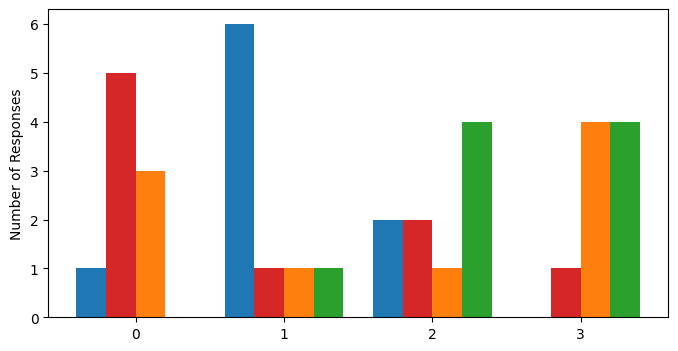

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import io
import numpy as np

# --- 1. Load and Prepare the Data ---

# Store the provided CSV data in a string.
# In a real scenario, you would replace this with:
# df = pd.read_csv('Feedback_app (Responses).csv')
csv_data = """
Timestamp,Cosa Le è piaciuto di più nell'usare questa app per ottenere i dati dai suoi sensori? C'è qualche funzionalità in particolare che ritiene possa aver facilitato il suo lavoro?,"C'è qualche aspetto che ha trovato confuso, lento o complesso quando ha usato l'app per recuperare i dati? ","C'è qualche funzionalità  che all'inizio trovava poco chiara o difficile da usare, e che poi è migliorata dopo un aggiornamento dell'app? Se sì, quale?","Le chiediamo di mettere in ordine di importanza i seguenti aspetti, in base alla propria esperienza (da 1, il più importante, a 4, il meno importante):     [Velocità: Ottenere i dati dai sensori molto rapidamente.]","Le chiediamo di mettere in ordine di importanza i seguenti aspetti, in base alla propria esperienza (da 1, il più importante, a 4, il meno importante):     [Costo: Mantenere il più basso possibile il costo per usare il sistema e ottenere i dati.]","Le chiediamo di mettere in ordine di importanza i seguenti aspetti, in base alla propria esperienza (da 1, il più importante, a 4, il meno importante):     [Sicurezza: Avere la certezza che i dati della sua azienda siano al sicuro, privati e non possano essere modificati.]","Le chiediamo di mettere in ordine di importanza i seguenti aspetti, in base alla propria esperienza (da 1, il più importante, a 4, il meno importante):     [Impatto ambientale: Sapere che la tecnologia consuma meno energia possibile.]","Immagini la presenza di un'assicurazione integrata nel nostro sistema. Se i suoi sensori rilevano un evento dannoso (come una forte gelata), il sistema è in grado di avviare  il rimborso presso l’assicurazione, senza che Lei debba compilare alcuna richiesta. Questo sistema si basa su dati oggettivi (come la temperatura) registrati in modo sicuro e non modificabile. L'idea di un rimborso basato su dati reali, invece che sull'interpretazione di un perito, La farebbe sentire più tutelato?","Per rendere la misurazione più affidabile, il sistema potrebbe usare anche i dati (in forma anonima) dei sensori di aziende agricole vicine. L'idea di contribuire con i propri dati per creare un sistema “cooperativo” Le sembra positiva?","Se un'assicurazione automatica di questo tipo fosse disponibile, per quali rischi specifici (es. gelate tardive, siccità, grandine, eccesso di pioggia) La riterrebbe più utile?",Quali dubbi o preoccupazioni avrebbe prima di affidarsi completamente a un sistema di assicurazione automatico gestito da sensori e tecnologia?,"C'è qualcos'altro che vorrebbe dirci sulla sua esperienza, o qualche idea o suggerimento per il futuro?"
7/17/2025 13:31:18,"Al momento uso di più: tabella con riepilogo temperature (molto utile l'ultima implementazione in cui posso impostare il range di tempo, da estendere anche a tutto il resto), tabella con riepilogo piogge (sposterei la colonna delle piogge della giornata subito dopo l'intensità della pioggia), tabella con riepilogo umidità del suolo e soprattutto il grafico dell'umidità del suolo","La mappa con i campi potrebbe essere più chiara. Vedo che i campi cambiano colore in base a cosa scelgo (WS o EM) ma non è molto chiaro a quale valore è associato il colore. Sopratutto per quanto riguarda il grafico dell'umidità del suolo dei sensori vorrei poter selezionare più facilmente il range temporale (come avete fatto con la tabella delle temperature) e vorrei poter visionare un periodo molto più esteso. Al momento risultano gestibili dalla dasboard solo 5 giorni. Sarebbe più comodo riuscire ad avere il grafico di almeno 10 gg, se non di più ",Le piogge,4,3,2,1,"Non ho campi, ma in linea generale, se abbiamo la certezza che i sensori rilevano i dati correttamente potrebbe essere interessante.",Si,"Siccità, eccesso di pioggia, gelate tardive",Il malfunzionamento dei sensori,No :)
7/17/2025 22:36:05,La versatilità nel cercare e filtrare i dati in base all'analisi che voglio fare o alle informazioni che cerco.,"Se non sbaglio i sensori di terra sono identificati solo con un numero, e non riesco a capire di quale sensore si tratti, come zona geografica ","Si, la prima è l'assegnazione del nome geografico alle stazioni meteo, la seconda è la possibilità di vedere i millimetri di pioggia che sono caduti in un determinato periodo e non solo dalla Mezzanotte precedente ",3,2,4,1,"Credo non sia così semplice, i fattori che intervengono sono diversi e non solo la temperatura, ma credo che sarebbe un ottimo supporto in una trattativa con il liquidatore ",Sarebbe fantastico ,Credo per tutte ,"Come dicevo non è mai un solo fattore che genera un danno in campagna, ma è sempre un insieme, potrebbe essere difficile riuscire a valutare automaticamente varie combinazioni di rischio.","Sarebbe fondamentale lavorare sull'interpretazione del dato, o dei dati per fornire a noi agricoli uno strumento concreto di supporto alla coltivazione. Per arrivare in futuro ad elaborare predizioni sulla base dei dati raccolti e sulla loro storicità "
7/17/2025 22:51:20,"
Sicuramente l'umidità del terreno, come aiuto nella gestione dell'irrigazione.",Sicuramente andrebbe ottimizzato per lo smartphone,No,2,1,3,4,"Decisamente sì, anche per eventuali danni da colpo di calore, eccesso idrico e forte vento.","Molto, anche nell'ottica di un'applicazione in campo assicurativo ","Gelo, grandine, eccesso di calore e di pioggia","È necessaria una sperimentazione su scala non troppo ristretta, e una buona diffusione dei sensori sul territorio. 
","Suggerisco un progetto pilota su media scala cofinanziato da psr, per poi procedere ad istituire un apposito bando per favorirne la diffusione.
Potrebbe essere un modo per contrastare la sempre più scarsa adesione alle assicurazioni in agricoltura.
"
7/18/2025 15:46:00,"La piovosità del giorno è umidità Dell aria
","Si, l umidità del suolo
","Inizialmente la grafica non mi soddisfava, ora molto meglio ",1,3,4,2,Non so quanto possa essere credibile ,Certamente ,Al momento ni,La non conoscenza Dell argomento ,Mi piacerebbe se fosse possibile avere il dato temperatura bulbo umido
7/18/2025 16:57:12,Poter intervenire nel momento più adatto ,No,No,1,2,3,4,Sì ,Se usano la stessa tecnologia si,Eccesso di pioggia grandine vento forte colpo di sole,La veridicità degli effettivi danni sulla pianta ,No
7/18/2025 18:42:30,quantitativo di pioggia e umidita,e abbastanza semplice da usare,mi sembra sia tutto chiaro,1,2,4,3,"buona idea, bisogna studiarla bene nei regolamenti","altra idea buona, regolamentarla bene e massima correttezza  operativa",con il tempo pazzo che  stiamo vivendo bisognerebbe prima  fare una analisi  degli ultimi  anni per capire quale dei rischi sopra menzionati impatta maggiormente sulla azienda,provarlo  con tanta attenzione alle regole ,nessuna proposta
7/18/2025 21:01:36,La facilità e la rapidità di accesso ai dati. La visualizzazione grafica dei dati restituisce una panoramica generale immediata delle informazioni.,No. Tutto facilmente intuibile ,La posizione dei sensori. Adesso è possibile visualizzare sulla mappa la posizione dei sensori ,1,3,4,2,Si,Assolutamente si,"gelate tardive, siccità, eccesso di pioggia",Nessuno,Nessuna
7/19/2025 10:25:33,Ancora dobbiamo prendere confidenza con i sensori nel terreno. Sicuramente le centraline meteo sono molto utili per la piovosità e soprattutto l'umidità ,Il sistema è forse macchinoso ai primi utilizzi ,La difficoltà maggiore è interpretare i dati,1,2,3,4,Sicuramente è una cosa interessante ,Molto positiva e sicuramente utile per tutti,Siccità e grandine ,Nessuno se fosse un sistema adottato da tutte le compagnie altrimenti ci sarebbero sicuramente disparità legato al fattore umano,Nessuna
7/26/2025 7:05:37,Tutte,Le scale delle unità di misura,I grafici,1,2,3,4,Si,Si,Tutte,"Le soglie alte che impongono le assicurazioni, con delle stazioni che danno valori definitivi ai rischia di non superare per pochi centesimi",Ci vorrebbero più stazioni sul territorio
"""

# Use io.StringIO to let pandas read the string as if it were a file
df = pd.read_csv(io.StringIO(csv_data))

# Define the full column names and their desired shorter labels
column_mapping = {
    "Le chiediamo di mettere in ordine di importanza i seguenti aspetti, in base alla propria esperienza (da 1, il più importante, a 4, il meno importante):     [Costo: Mantenere il più basso possibile il costo per usare il sistema e ottenere i dati.]": "Cost",
    "Le chiediamo di mettere in ordine di importanza i seguenti aspetti, in base alla propria esperienza (da 1, il più importante, a 4, il meno importante):     [Velocità: Ottenere i dati dai sensori molto rapidamente.]": "Speed",
    "Le chiediamo di mettere in ordine di importanza i seguenti aspetti, in base alla propria esperienza (da 1, il più importante, a 4, il meno importante):     [Impatto ambientale: Sapere che la tecnologia consuma meno energia possibile.]": "Environmental Impact",
    "Le chiediamo di mettere in ordine di importanza i seguenti aspetti, in base alla propria esperienza (da 1, il più importante, a 4, il meno importante):     [Sicurezza: Avere la certezza che i dati della sua azienda siano al sicuro, privati e non possano essere modificati.]": "Security",
}

# Select and rename the relevant columns
ranking_df = df[list(column_mapping.keys())].rename(columns=column_mapping)

# Calculate the frequency of each rank (1, 2, 3, 4) for each category
# The result is a dictionary where keys are categories and values are Series of counts
counts = {col: ranking_df[col].value_counts() for col in ranking_df.columns}

# Convert the dictionary of counts into a DataFrame for easier plotting
# We reindex to ensure all ranks [1, 2, 3, 4] are present for each category, filling missing values with 0
plot_df = pd.DataFrame(counts).reindex([1, 2, 3, 4]).fillna(0).astype(int)


# --- 2. Create the Plot ---

# Define categories and ranks
categories = plot_df.columns
ranks = plot_df.index
n_categories = len(categories)
n_ranks = len(ranks)

# Define colors for each rank to match the original image
colors = {
    1: "#1f77b4",  # Blue
    2: "#d62728",  # Red
    3: "#ff7f0e",  # Orange
    4: "#2ca02c",  # Green
}

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 4))

# Set bar width and positions
bar_width = 0.2
index = np.arange(n_categories)

# Create bars for each rank
for i, rank in enumerate(ranks):
    # Calculate position for each group of bars
    position = index - (bar_width * (n_ranks - 1) / 2) + (i * bar_width)
    bar_values = plot_df.loc[rank]
    ax.bar(position, bar_values, bar_width, label=f"Rank {rank}", color=colors[rank])

# --- 3. Format the Plot ---

# Add labels and title
ax.set_ylabel("Number of Responses")
ax.set_xticks(index)
# Use shorter labels for clarity on the x-axis
xtick_labels = [
    "F1. Cost",
    "F2. Performance",
    "F4. Environmental ImpactF3. Security",
]
ax.set_xticklabels(xtick_labels)

# Set y-axis to have integer ticks, starting from 0
max_y = plot_df.max().max()
ax.set_yticks(np.arange(0, max_y + 2, 2))  # Ticks every 2 units
ax.set_ylim(0, max_y + 1)

# Add legend
ax.legend(title="Importance Rank")

# Add a grid for better readability
ax.yaxis.grid(True, linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Show the plot
plt.show()

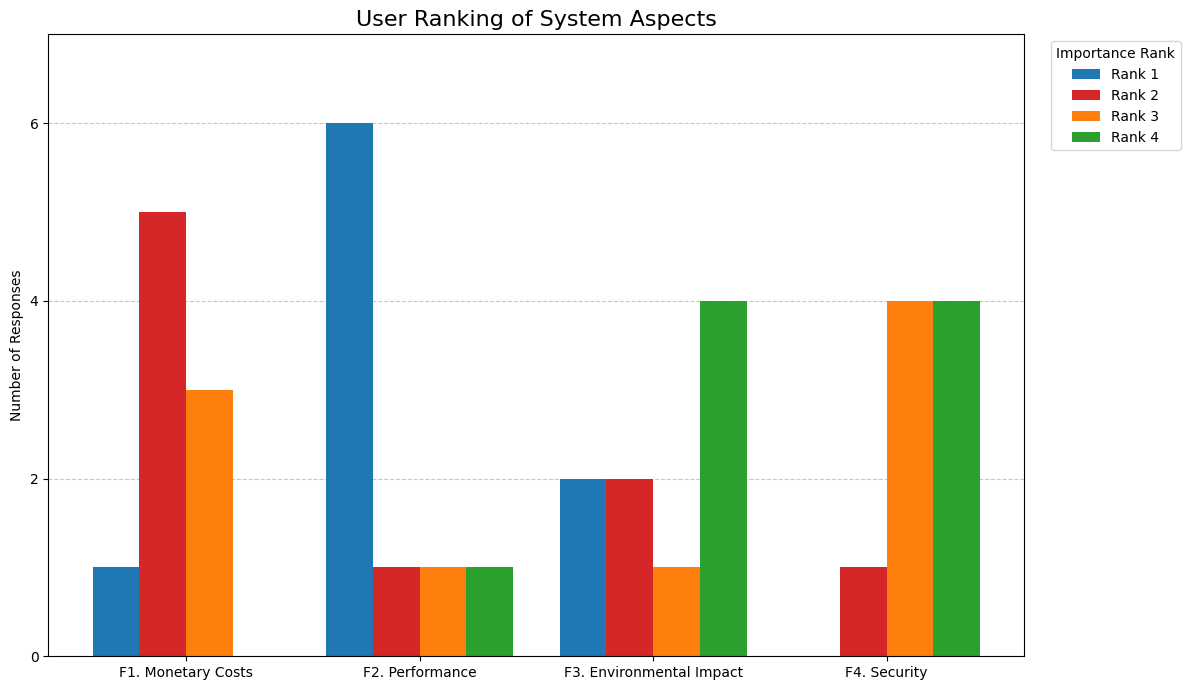

In [ ]:
# Create a figure with 1 row and 4 columns of subplots
# sharey=True ensures all plots use the same y-axis scale for fair comparison
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(14, 5), sharey=True)

# Define colors for each rank (as a list for easy indexing)
bar_colors = ['#1f77b4', '#d62728', '#ff7f0e', '#2ca02c']
categories = plot_df.columns
ranks = plot_df.index

# Loop through each category and create a bar plot on its own axis
for i, category in enumerate(categories):
    ax = axes[i]
    ax.bar(ranks, plot_df[category], color=bar_colors)
    ax.set_title(category)
    ax.set_xlabel('Rank')
    ax.set_xticks(ranks) # Ensure all ranks are shown as ticks

# Set a single y-label for the entire figure
axes[0].set_ylabel('Number of Responses')

# Add a main title for the entire figure
fig.suptitle('Ranking Distribution for Each Category', fontsize=16, y=1.03)

# Improve layout
plt.tight_layout()
plt.show()

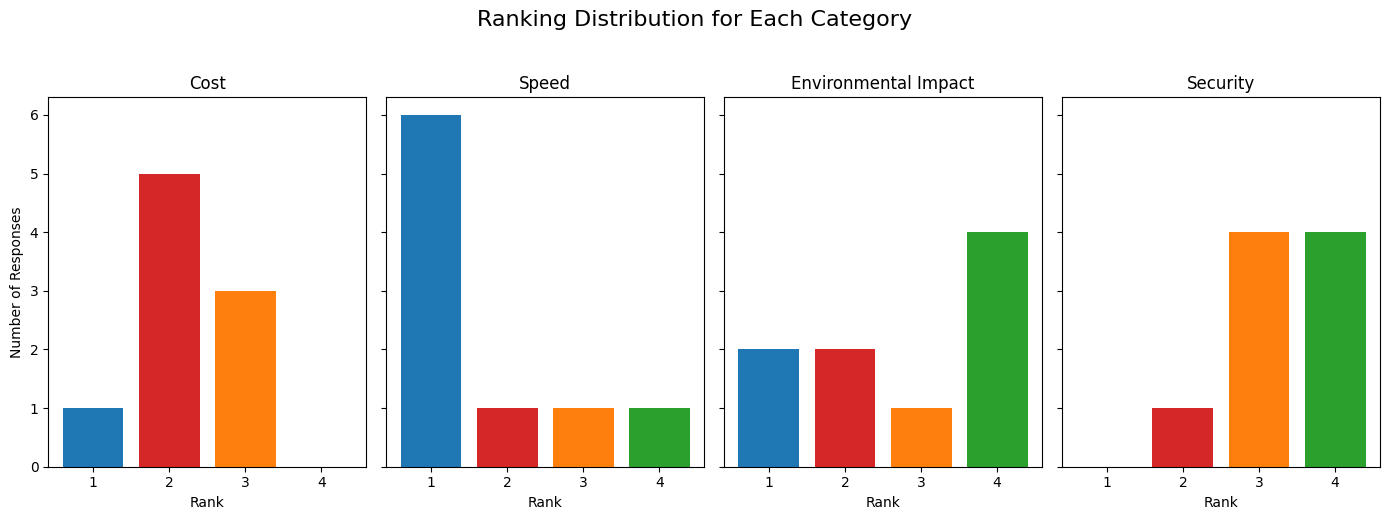

In [14]:
# Create a figure with 1 row and 4 columns of subplots
# sharey=True ensures all plots use the same y-axis scale for fair comparison
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(14, 5), sharey=True)

# Define colors for each rank (as a list for easy indexing)
bar_colors = ['#1f77b4', '#d62728', '#ff7f0e', '#2ca02c']
categories = plot_df.columns
ranks = plot_df.index

# Loop through each category and create a bar plot on its own axis
for i, category in enumerate(categories):
    ax = axes[i]
    ax.bar(ranks, plot_df[category], color=bar_colors)
    ax.set_title(category)
    ax.set_xlabel('Rank')
    ax.set_xticks(ranks) # Ensure all ranks are shown as ticks

# Set a single y-label for the entire figure
axes[0].set_ylabel('Number of Responses')

# Add a main title for the entire figure
fig.suptitle('Ranking Distribution for Each Category', fontsize=16, y=1.03)

# Improve layout
plt.tight_layout()
plt.show()

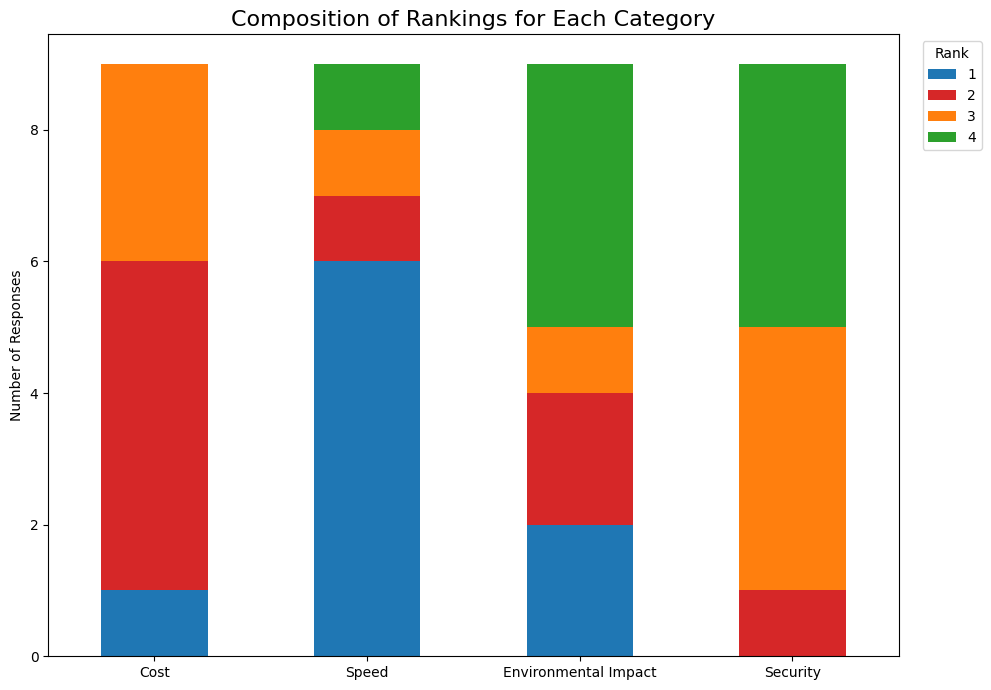

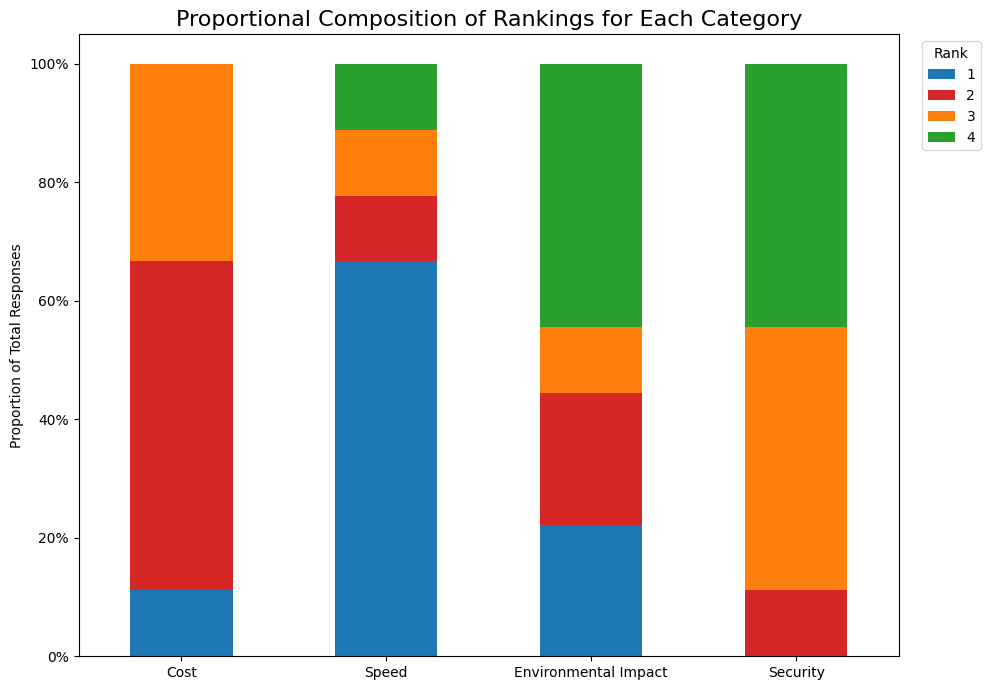

In [17]:
# --- 1. Standard Stacked Bar Chart ---

# Transpose the DataFrame so categories are on the x-axis
plot_df_transposed = plot_df.T

# Define colors for each rank
colors = {1: '#1f77b4', 2: '#d62728', 3: '#ff7f0e', 4: '#2ca02c'}

# Create the stacked bar plot
ax = plot_df_transposed.plot(
    kind='bar',
    stacked=True,
    color=colors,
    figsize=(10, 7),
    rot=0 # Keep x-axis labels horizontal
)

# Formatting
ax.set_title('Composition of Rankings for Each Category', fontsize=16)
ax.set_ylabel('Number of Responses')
ax.set_xlabel('') # Remove the default x-axis label
ax.legend(title='Rank', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


# --- 2. 100% Stacked Bar Chart (for Proportions) ---

# Normalize the data to sum to 1 (or 100%)
df_normalized = plot_df_transposed.div(plot_df_transposed.sum(axis=1), axis=0)

ax_norm = df_normalized.plot(
    kind='bar',
    stacked=True,
    color=colors,
    figsize=(10, 7),
    rot=0
)

# Formatting
ax_norm.set_title('Proportional Composition of Rankings for Each Category', fontsize=16)
ax_norm.set_ylabel('Proportion of Total Responses')
ax_norm.set_xlabel('')
# Format y-axis ticks as percentages
ax_norm.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax_norm.legend(title='Rank', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

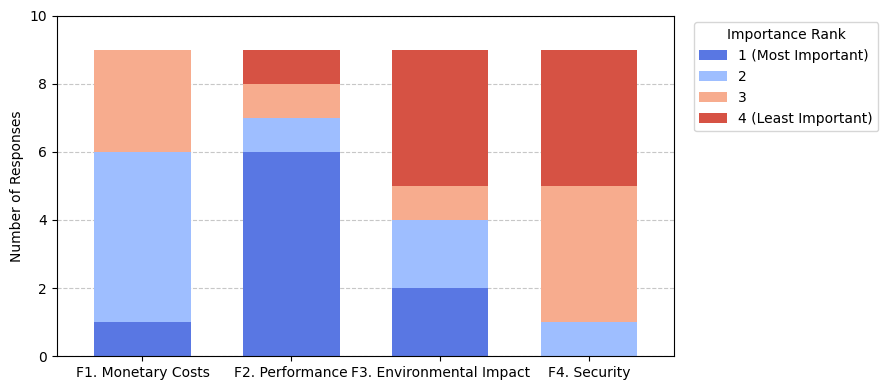

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Reorder Data and Define Labels ---

# Define the desired order of columns and the corresponding labels for the plot
category_order = ['Cost', 'Speed', 'Environmental Impact', 'Security']
xtick_labels = [
    'F1. Monetary Costs',
    'F2. Performance',
    'F3. Environmental Impact',
    'F4. Security'
]

# Reorder the DataFrame columns and transpose it for stacked plotting
# The plot function expects the categories for the x-axis to be rows.
plot_df_ordered = plot_df[category_order].T


# --- 2. Define the Color Palette ---

# Sequential 'Greens' palette from Matplotlib
# We sample from a colormap to get 4 distinct shades.
# np.linspace(0.8, 0.3, 4) samples from dark to light.
cmap = plt.get_cmap('coolwarm')
diverging_colors = [cmap(i) for i in [0.1, 0.3, 0.7, 0.9]] # Hand-picked 


# --- 3. Create and Format the Stacked Bar Chart ---

ax = plot_df_ordered.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 4),
    color=diverging_colors,
    rot=0, # Keep x-axis labels horizontal
    width=0.65 # Adjust bar width for aesthetics
)

# Add titles and labels
ax.set_ylabel('Number of Responses')
ax.set_xlabel('') # Categories are clear, no need for an axis title

# Apply the custom x-axis labels
ax.set_xticklabels(xtick_labels)

# Add horizontal grid lines every 2 ticks
max_y = plot_df_ordered.sum(axis=1).max()
y_ticks = np.arange(0, max_y + 2, 2)
ax.set_yticks(y_ticks)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

# Format the legend
ax.legend(
    title='Importance Rank',
    labels=['1 (Most Important)', '2', '3', '4 (Least Important)'],
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()

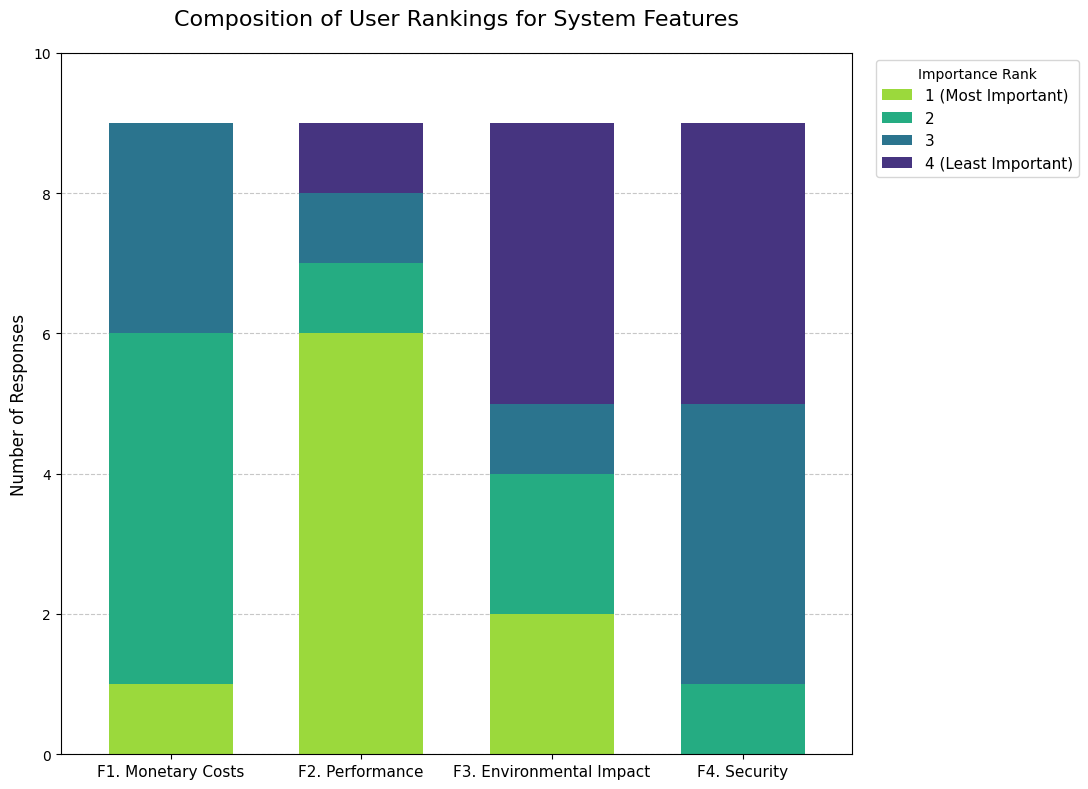

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Reorder Data and Define Labels ---

# Define the desired order of columns and the corresponding labels for the plot
category_order = ['Cost', 'Speed', 'Environmental Impact', 'Security']
xtick_labels = [
    'F1. Monetary Costs',
    'F2. Performance',
    'F3. Environmental Impact',
    'F4. Security'
]

# Reorder the DataFrame columns and transpose it for stacked plotting
# The plot function expects the categories for the x-axis to be rows.
plot_df_ordered = plot_df[category_order].T


# --- 2. Define the Color Palette ---

# Sequential 'Greens' palette from Matplotlib
# We sample from a colormap to get 4 distinct shades.
# Replace the color definition in the code above with this:
cmap = plt.get_cmap('viridis')
viridis_colors = [cmap(i) for i in np.linspace(0.85, 0.15, 4)]
# Then run the plot code again

# --- 3. Create and Format the Stacked Bar Chart ---

ax = plot_df_ordered.plot(
    kind='bar',
    stacked=True,
    figsize=(11, 8),
    color=viridis_colors,
    rot=0, # Keep x-axis labels horizontal
    width=0.65 # Adjust bar width for aesthetics
)

# Add titles and labels
ax.set_title('Composition of User Rankings for System Features', fontsize=16, pad=20)
ax.set_ylabel('Number of Responses', fontsize=12)
ax.set_xlabel('') # Categories are clear, no need for an axis title

# Apply the custom x-axis labels
ax.set_xticklabels(xtick_labels, fontsize=11)

# Add horizontal grid lines every 2 ticks
max_y = plot_df_ordered.sum(axis=1).max()
y_ticks = np.arange(0, max_y + 2, 2)
ax.set_yticks(y_ticks)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

# Format the legend
ax.legend(
    title='Importance Rank',
    labels=['1 (Most Important)', '2', '3', '4 (Least Important)'],
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=11
)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()